# XGBoost Forecasting With Dynamic Topology

This notebook inspects the final-resolution-only dynamic-topology experiment. It does not introduce volatility, move, or forecast-error targets. The target remains final binary market resolution `Y_i`.

## Optional Free External CPU Setup

Use this in Google Colab or Kaggle free CPU. Do not use paid runtimes.

```python
!git clone https://github.com/ajerfy/Topology-of-Prediction-Market-Belief-Dynamics.git
%cd Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology
!pip install -r requirements.txt
!python src/xgboost_forecasting_topological_dynamics.py --skip-existing --topology-stride-hours 24 --log-level INFO
```

To split work across free sessions, run a fold range per session, then combine:

```python
!python src/xgboost_forecasting_topological_dynamics.py --fold-start 1 --fold-end 6 --skip-existing
!python src/xgboost_forecasting_topological_dynamics.py --fold-start 7 --fold-end 12 --skip-existing
!python src/xgboost_forecasting_topological_dynamics.py --fold-start 13 --fold-end 17 --skip-existing
!python src/xgboost_forecasting_topological_dynamics.py --combine-fold-outputs
```

Outputs are written under `data/processed/`. No private credentials or paid compute are required.

In [1]:
from pathlib import Path
import sys

import pandas as pd

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUT = PROJECT / "data" / "processed"
FIG = OUT / "figures" / "xgb_forecasting_topology"
RESULTS = OUT / "xgb_forecasting_topology_results.csv"
PREDICTIONS = OUT / "xgb_forecasting_topology_predictions.parquet"
CALIBRATION = OUT / "xgb_forecasting_topology_calibration.csv"
STAT_TESTS = OUT / "xgb_forecasting_topology_stat_tests.csv"
SUMMARY = OUT / "xgb_forecasting_topology_summary.md"
RESULTS

PosixPath('/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/xgb_forecasting_topology_results.csv')

## Optional Full Run

Leave `RUN_FULL = False` unless recomputing the experiment.

In [2]:
RUN_FULL = False

if RUN_FULL:
    from xgboost_forecasting_topological_dynamics import run_all

    run_all(
        OUT / "candidate_universe_markets.parquet",
        OUT / "prices_long.parquet",
        OUT / "universe_b_macro_crypto_panel.parquet",
        OUT,
        None,
        None,
        True,
        24,
    )

In [3]:
results = pd.read_csv(RESULTS)
predictions = pd.read_parquet(PREDICTIONS)
calibration = pd.read_csv(CALIBRATION)
stat_tests = pd.read_csv(STAT_TESTS)
print(SUMMARY.read_text())
results.head()

XGBOOST FORECASTING TOPOLOGY SUMMARY

Overall ranking:
- logit_pca_controls_static_topology: log loss 0.128668, Brier 0.034442, AUC 0.958828
- logit_pca_controls: log loss 0.135540, Brier 0.036162, AUC 0.949246
- logit_pca_controls_static_dynamic_topology: log loss 0.137280, Brier 0.036215, AUC 0.955087
- xgb_pca_controls: log loss 0.138198, Brier 0.039105, AUC 0.974754
- xgb_pca_controls_dynamic_topology: log loss 0.138363, Brier 0.038945, AUC 0.974835
- xgb_pca_controls_static_dynamic_topology: log loss 0.139005, Brier 0.039312, AUC 0.975640
- xgb_pca_controls_static_topology: log loss 0.139038, Brier 0.039381, AUC 0.975474
- logit_pca_controls_dynamic_topology: log loss 0.144773, Brier 0.038154, AUC 0.946480
- market_probability: log loss 0.167262, Brier 0.048879, AUC 0.941865

Key answers:
- Does dynamic topology improve XGBoost final-resolution forecasting? no
- XGBoost dynamic topology gain: log loss -0.000166, Brier +0.000160
- Does dynamic topology improve logistic final-resolu

,fold,model,model_type,feature_group,slice_type,slice_value,n_obs,brier,log_loss,avg_pred,avg_actual,auc
0,1,market_probability,market,market,overall,overall,14850,0.071043,0.237257,0.179406,0.086532,0.915515
1,1,market_probability,market,market,broad_domain,crypto,5721,0.102927,0.328372,0.232716,0.000000,NaN
2,1,market_probability,market,market,broad_domain,macro,9129,0.051062,0.180157,0.145997,0.140760,0.967171
3,1,market_probability,market,market,broad_family,crypto_btc,3112,0.103830,0.317257,0.219733,0.000000,NaN
4,1,market_probability,market,market,broad_family,crypto_eth,1937,0.130053,0.409827,0.288019,0.000000,NaN


## Overall Ranking

In [4]:
overall = (
    results[results["slice_type"].eq("overall")]
    .groupby(["model", "model_type", "feature_group"], as_index=False)
    .agg(folds=("fold", "nunique"), n_obs=("n_obs", "sum"), log_loss=("log_loss", "mean"), brier=("brier", "mean"), auc=("auc", "mean"))
    .sort_values("log_loss")
)
overall

,model,model_type,feature_group,folds,n_obs,log_loss,brier,auc
3,logit_pca_controls_static_topology,logit,pca_controls_static,17,282976,0.128668,0.034442,0.958828
0,logit_pca_controls,logit,pca_controls,17,282976,0.135540,0.036162,0.949246
2,logit_pca_controls_static_dynamic_topology,logit,pca_controls_static_dynamic,17,282976,0.137280,0.036215,0.955087
5,xgb_pca_controls,xgb,pca_controls,17,282976,0.138198,0.039105,0.974754
6,xgb_pca_controls_dynamic_topology,xgb,pca_controls_dynamic,17,282976,0.138363,0.038945,0.974835
7,xgb_pca_controls_static_dynamic_topology,xgb,pca_controls_static_dynamic,17,282976,0.139005,0.039312,0.975640
8,xgb_pca_controls_static_topology,xgb,pca_controls_static,17,282976,0.139038,0.039381,0.975474
1,logit_pca_controls_dynamic_topology,logit,pca_controls_dynamic,17,282976,0.144773,0.038154,0.946480
4,market_probability,market,market,17,282976,0.167262,0.048879,0.941865


## Figures

log_loss_ranking.png


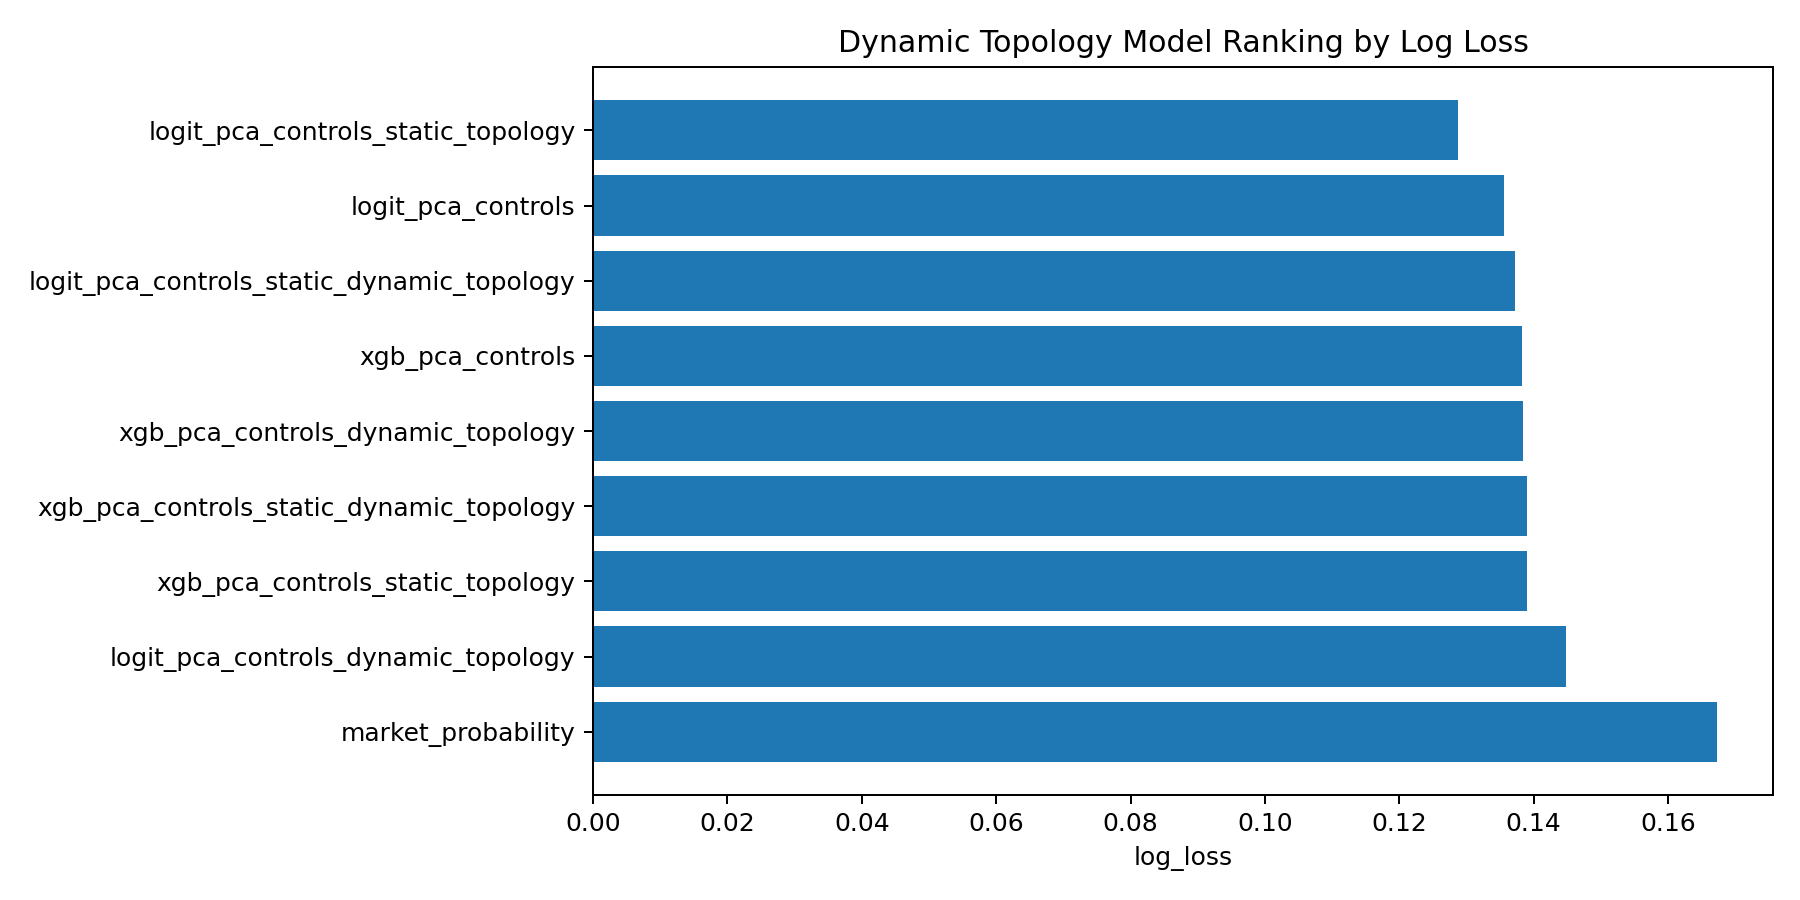

brier_ranking.png


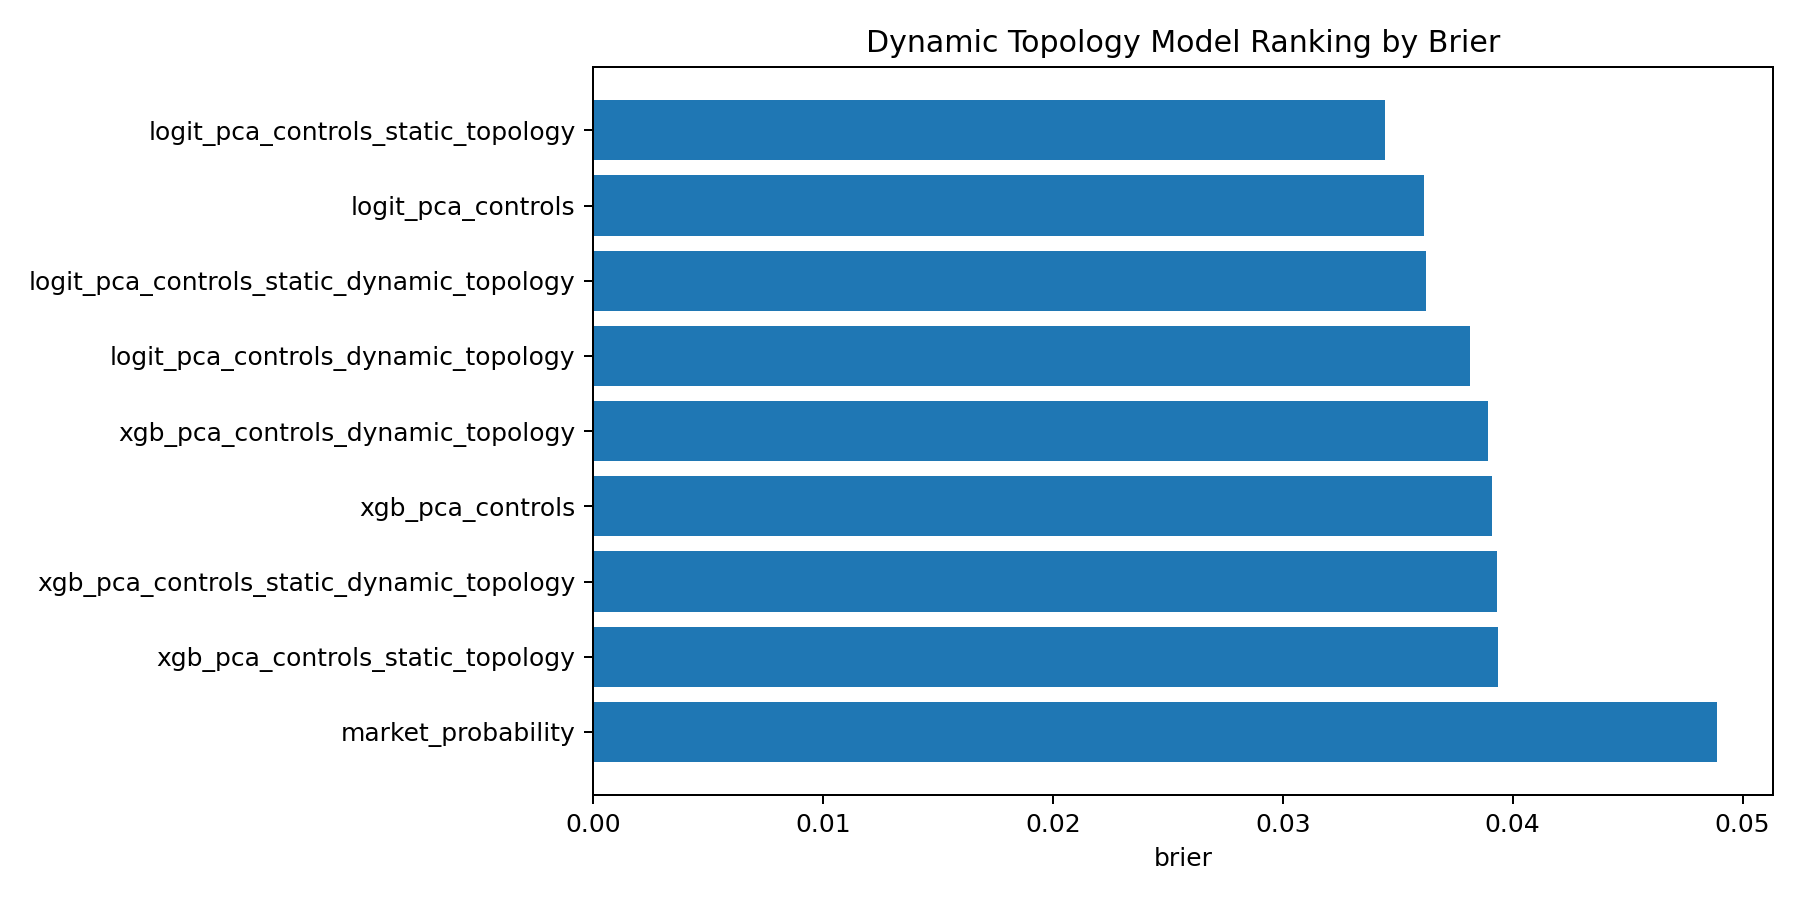

fold_level_deltas.png


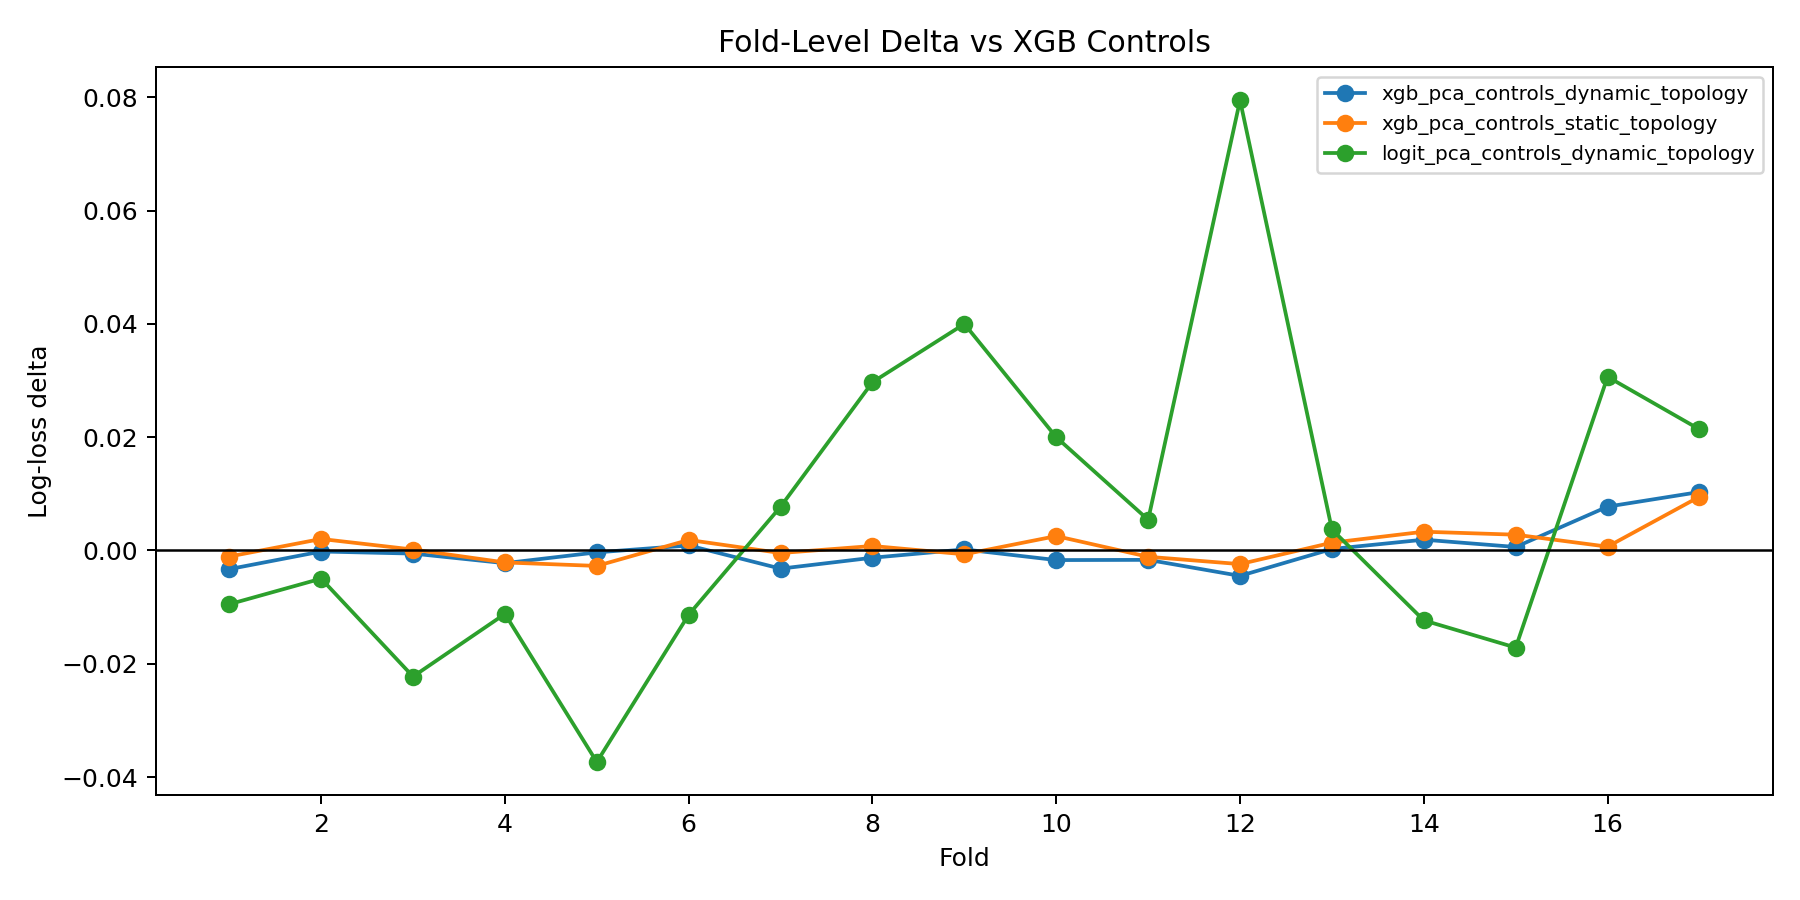

locked_holdout.png


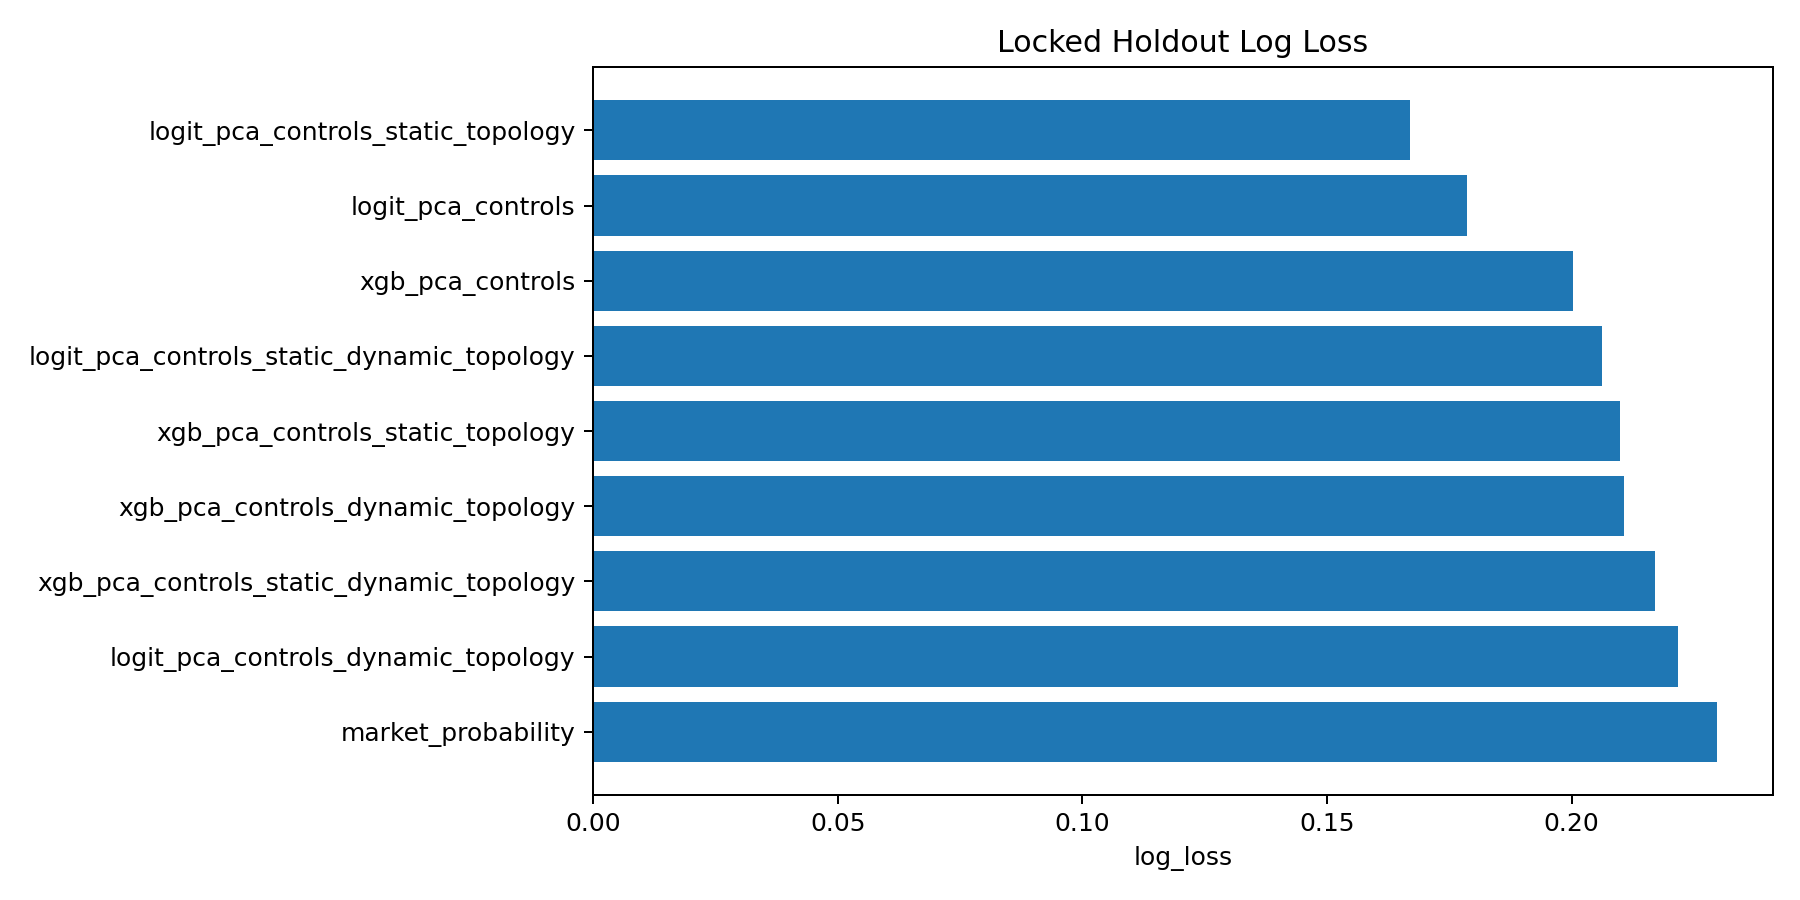

calibration_curves.png


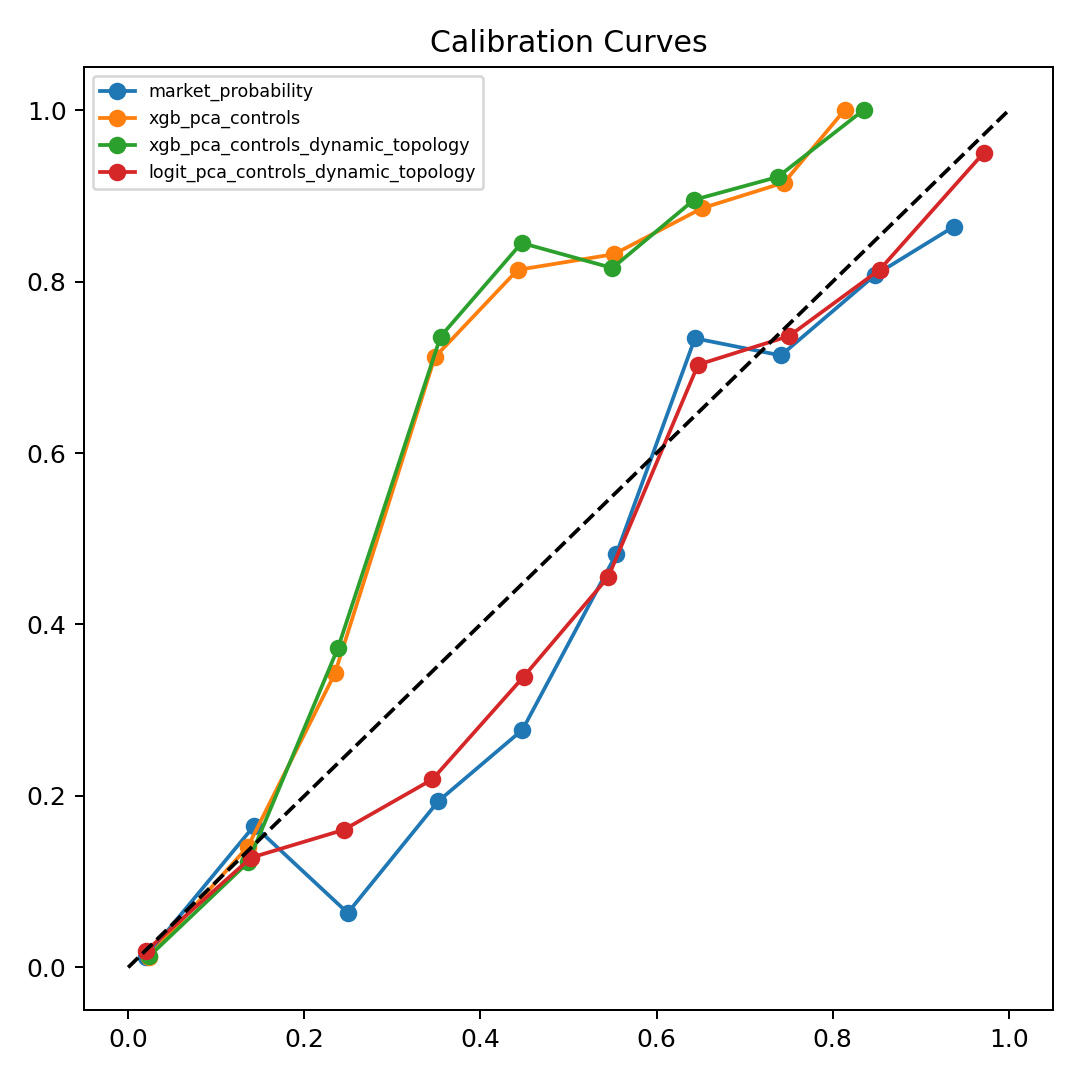

bootstrap_ci.png


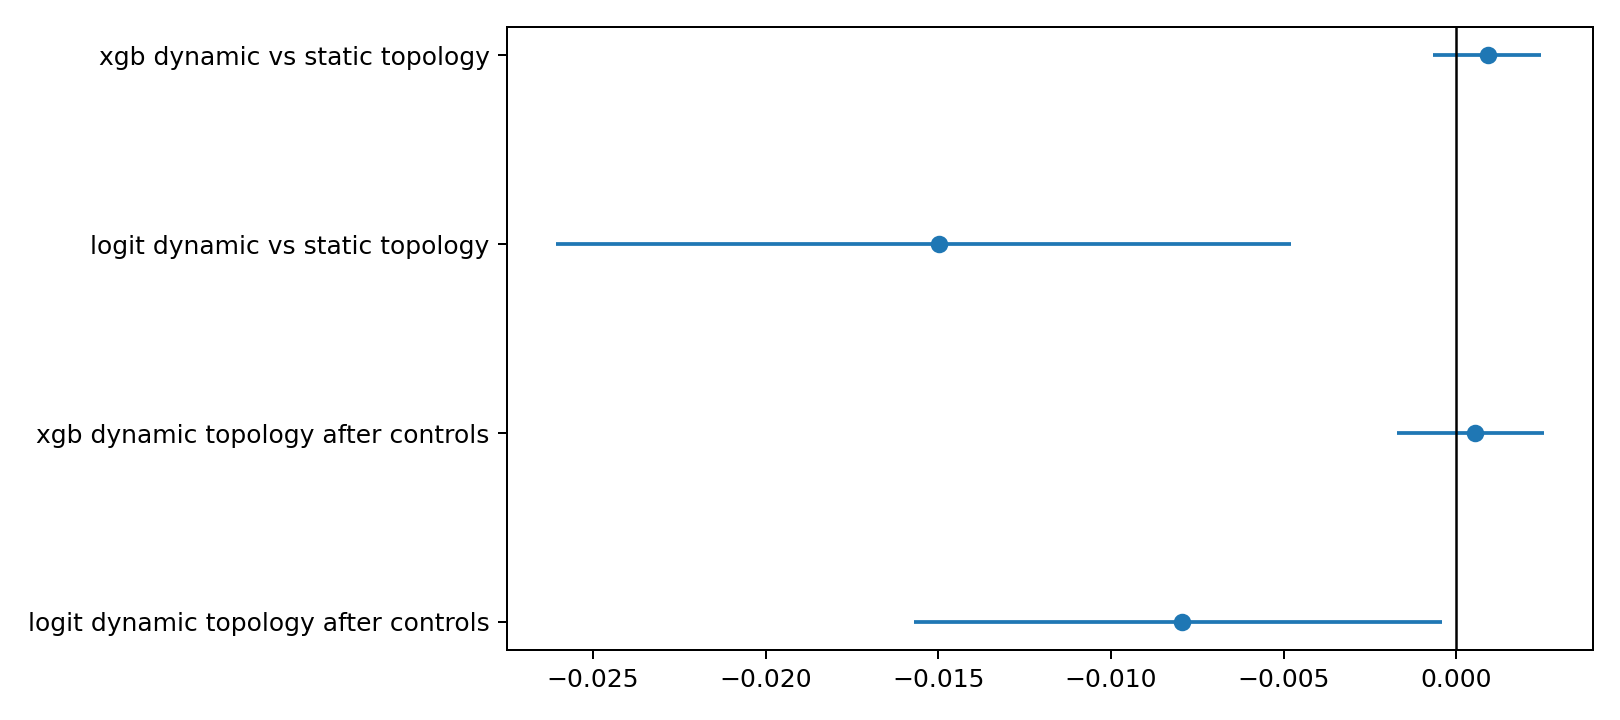

domain_level_gain.png


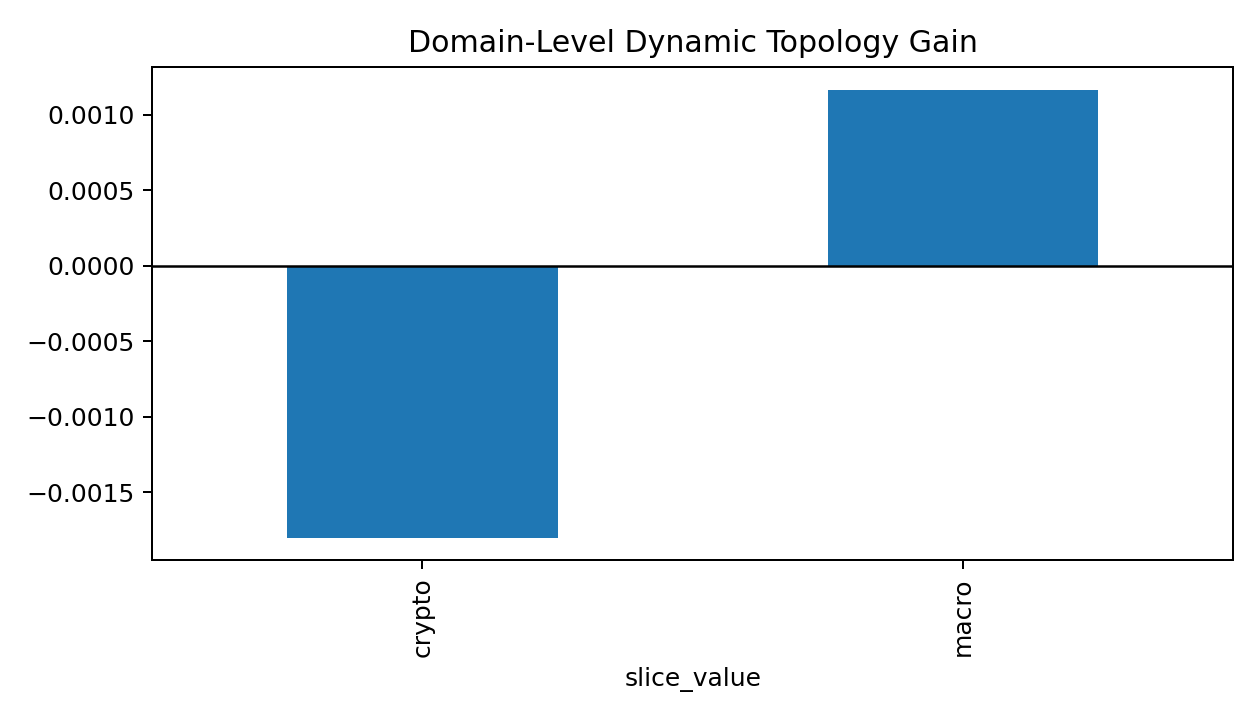

static_dynamic_ablation.png


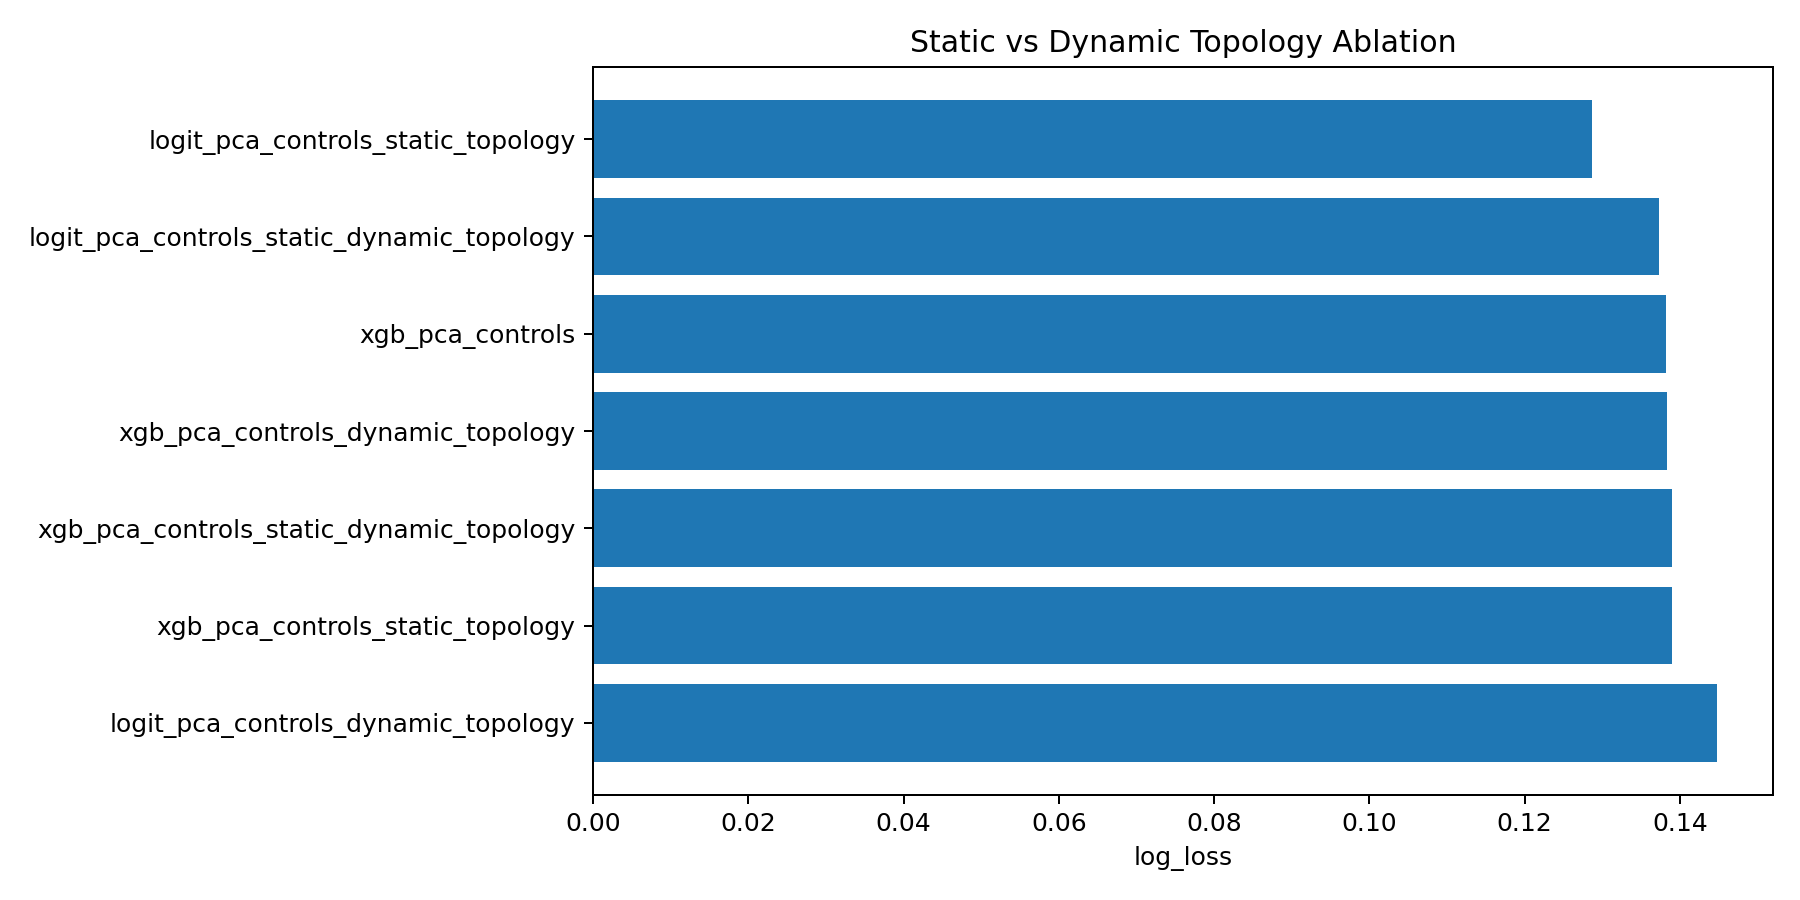

xgboost_feature_comparison.png


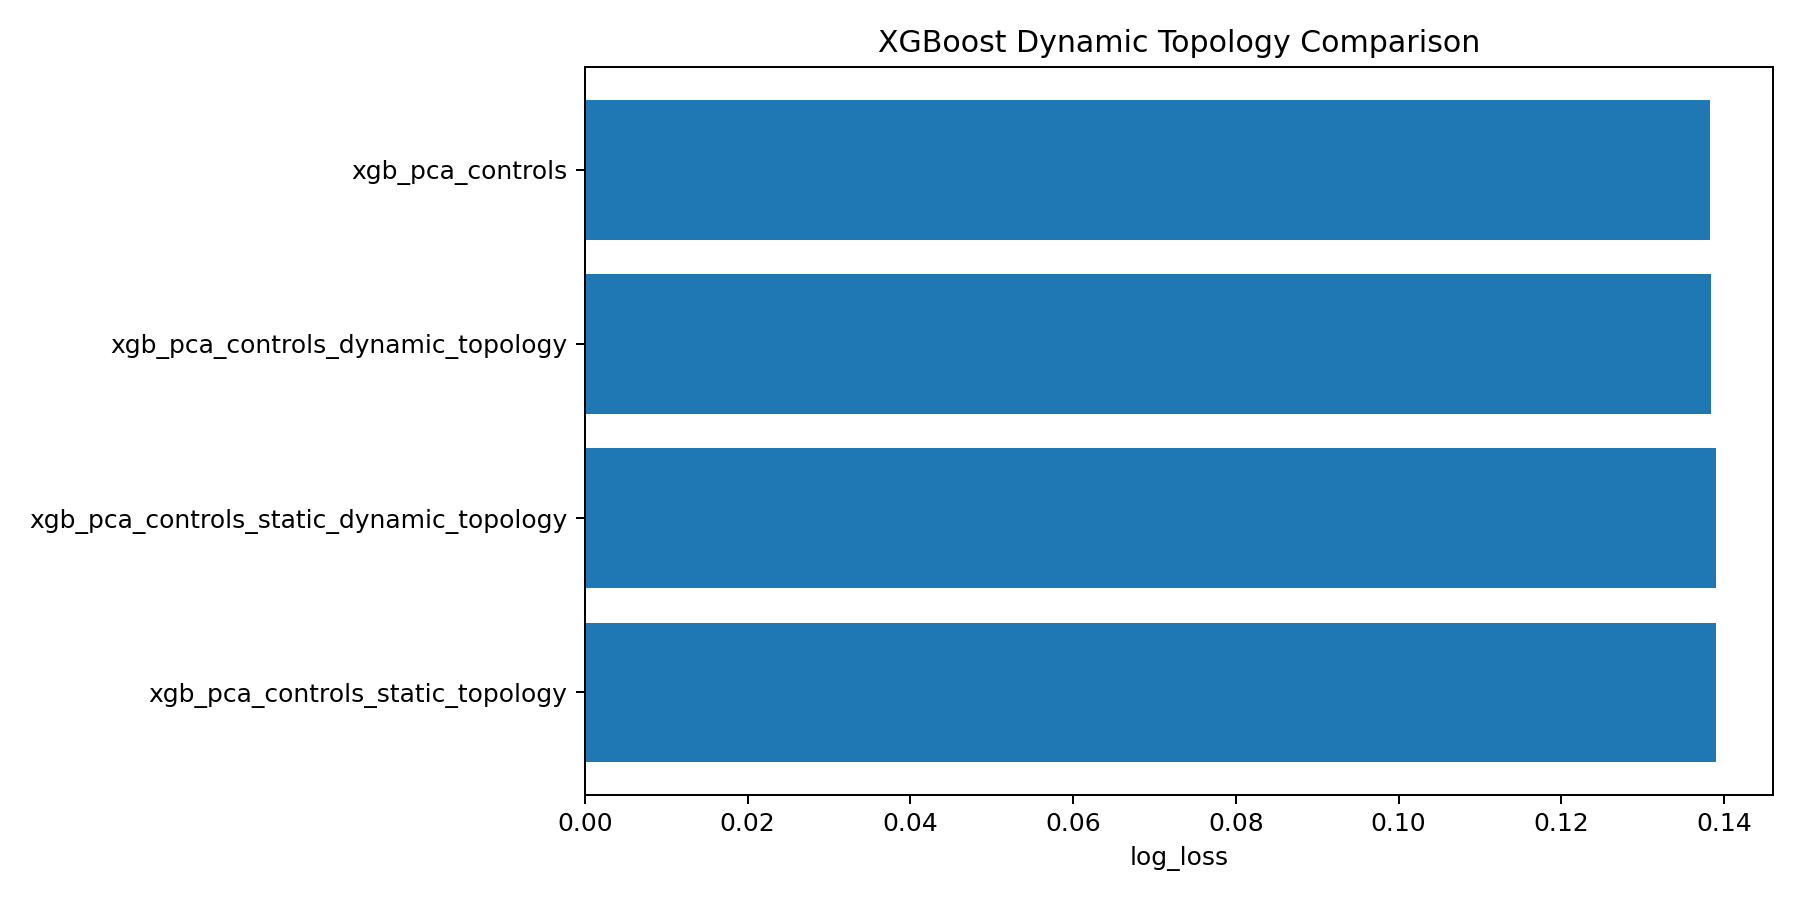

xgboost_feature_importance.png


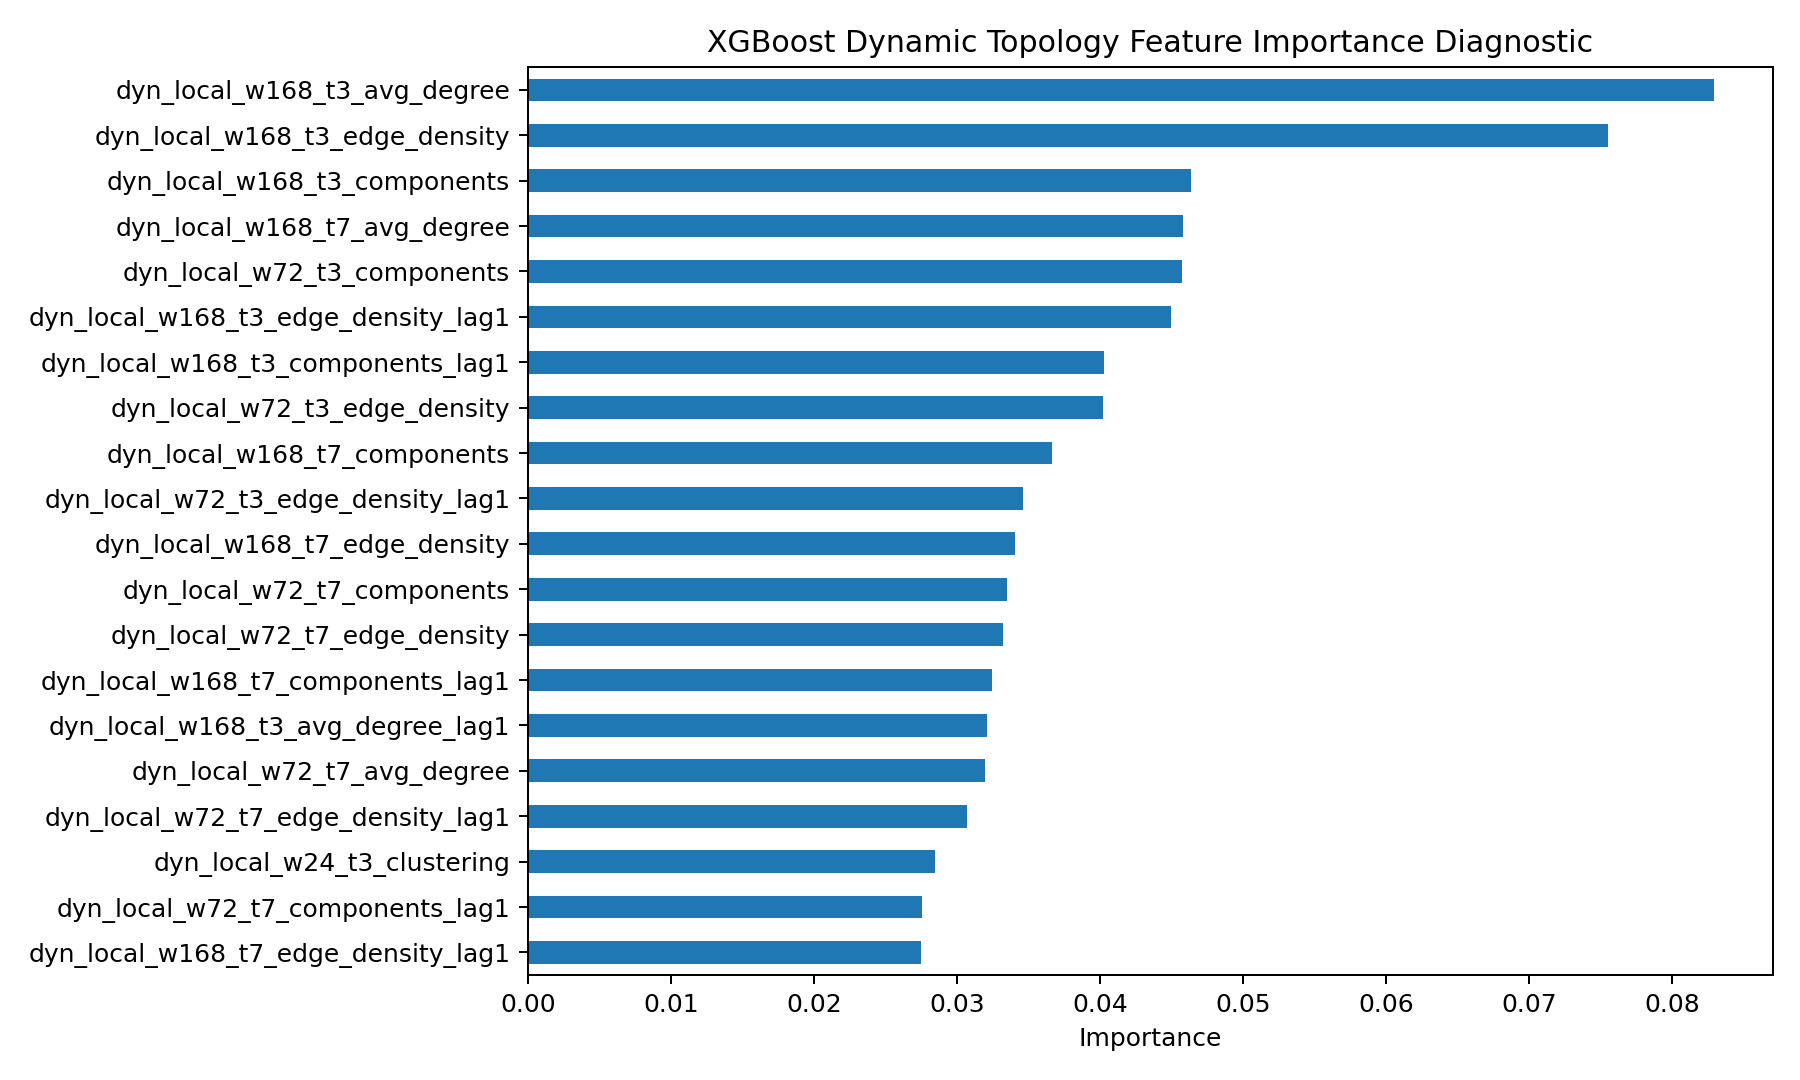

dynamic_topology_timeseries.png


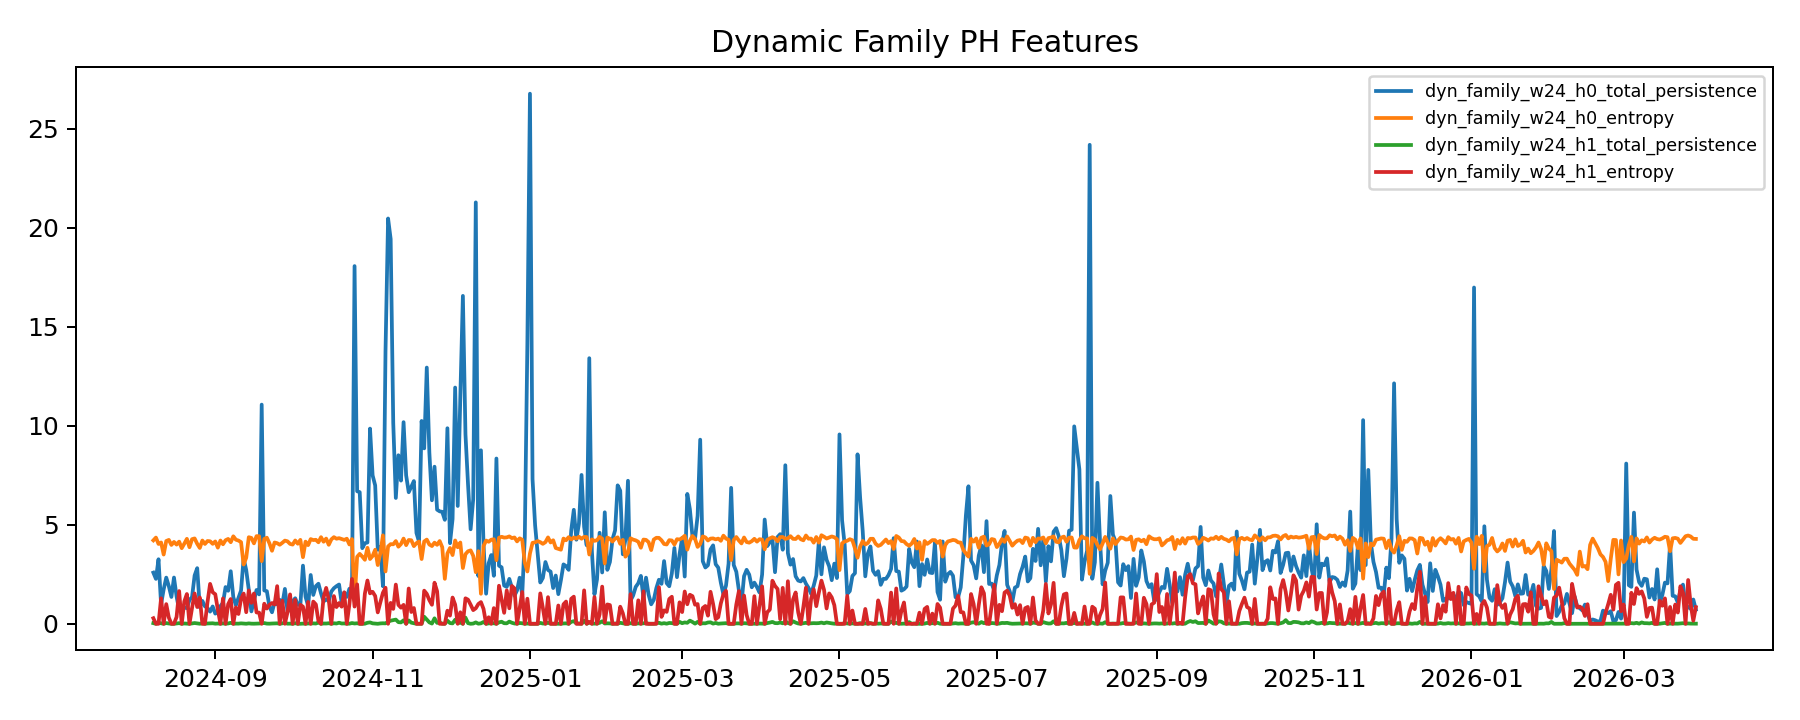

In [5]:
from IPython.display import Image, display

for name in [
    "log_loss_ranking.png",
    "brier_ranking.png",
    "fold_level_deltas.png",
    "locked_holdout.png",
    "calibration_curves.png",
    "bootstrap_ci.png",
    "domain_level_gain.png",
    "static_dynamic_ablation.png",
    "xgboost_feature_comparison.png",
    "xgboost_feature_importance.png",
    "dynamic_topology_timeseries.png",
]:
    print(name)
    display(Image(filename=str(FIG / name)))

## Statistical Tests

In [6]:
stat_tests

,comparison,candidate,baseline,cluster,n_units,log_loss_gain,log_loss_ci_low,log_loss_ci_high,brier_gain,brier_ci_low,brier_ci_high
0,logit dynamic topology after controls,logit_pca_controls_dynamic_topology,logit_pca_controls,row,282976,-0.007950,-0.008333,-0.007602,-0.001980,-0.002108,-0.001876
1,logit dynamic topology after controls,logit_pca_controls_dynamic_topology,logit_pca_controls,market_id,105,-0.007950,-0.015709,-0.000404,-0.001980,-0.004510,0.000669
2,logit dynamic topology after controls,logit_pca_controls_dynamic_topology,logit_pca_controls,timestamp,5712,-0.007950,-0.008536,-0.007431,-0.001980,-0.002122,-0.001835
3,xgb dynamic topology after controls,xgb_pca_controls_dynamic_topology,xgb_pca_controls,row,282976,0.000530,0.000460,0.000599,0.000300,0.000274,0.000322
4,xgb dynamic topology after controls,xgb_pca_controls_dynamic_topology,xgb_pca_controls,market_id,105,0.000530,-0.001719,0.002531,0.000300,-0.000274,0.000903
5,xgb dynamic topology after controls,xgb_pca_controls_dynamic_topology,xgb_pca_controls,timestamp,5712,0.000530,0.000466,0.000586,0.000300,0.000279,0.000320
6,logit dynamic vs static topology,logit_pca_controls_dynamic_topology,logit_pca_controls_static_topology,row,282976,-0.014974,-0.015691,-0.014311,-0.003992,-0.004199,-0.003806
7,logit dynamic vs static topology,logit_pca_controls_dynamic_topology,logit_pca_controls_static_topology,market_id,105,-0.014974,-0.026055,-0.004798,-0.003992,-0.007217,-0.001164
8,logit dynamic vs static topology,logit_pca_controls_dynamic_topology,logit_pca_controls_static_topology,timestamp,5712,-0.014974,-0.015948,-0.014242,-0.003992,-0.004251,-0.003766
9,xgb dynamic vs static topology,xgb_pca_controls_dynamic_topology,xgb_pca_controls_static_topology,row,282976,0.000917,0.000836,0.001011,0.000470,0.000441,0.000501


## Calibration

In [7]:
calibration.groupby("model", as_index=False).agg(ece=("ece", "mean"), n_obs=("n_obs", "sum")).sort_values("ece")

,model,ece,n_obs
0,logit_pca_controls,0.031682,282976
1,logit_pca_controls_dynamic_topology,0.033902,282976
3,logit_pca_controls_static_topology,0.034724,282976
2,logit_pca_controls_static_dynamic_topology,0.036543,282976
5,xgb_pca_controls,0.048391,282976
7,xgb_pca_controls_static_dynamic_topology,0.050162,282976
6,xgb_pca_controls_dynamic_topology,0.050463,282976
8,xgb_pca_controls_static_topology,0.052259,282976
4,market_probability,0.058023,282976


## Interpretation

Dynamic topology does not improve beyond the existing final comparison for final binary outcome forecasting. It slightly improves XGBoost Brier but worsens XGBoost log loss; the final paper should keep the prior static local-topology logistic result as the main topology-enhanced finding.